# Блок 4. PCA и нейронная сеть прямого распространения для классификации

В этом ноутбуке рассматриваются две связанные задачи на новом датасете `Digits` из `scikit-learn`:

1. Снижение размерности методом главных компонент (`PCA`).
2. Классификация изображений цифр с помощью полносвязной нейронной сети (`MLPClassifier`).

Такой выбор позволяет не только изучить геометрию данных в пространстве меньшей размерности,
но и проверить, как уменьшение числа признаков влияет на качество модели классификации.

## О датасете Digits

Датасет `Digits` содержит `1797` наблюдений и `64` числовых признака.
Каждый объект - это изображение рукописной цифры размером `8x8`, развёрнутое в вектор длины `64`.
Значение каждого признака соответствует интенсивности пикселя.

Целевая переменная принимает `10` значений: от `0` до `9`.
Таким образом, задача классификации является многоклассовой.

Датасет хорошо подходит для `PCA`, потому что исходное пространство признаков довольно велико,
а визуально и численно интересно оценить, сколько компонент достаточно для сохранения
основной информации об изображениях.

In [5]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")

digits = load_digits()
pixel_columns = [f"pixel_{i}" for i in range(digits.data.shape[1])]
df_digits = pd.DataFrame(digits.data, columns=pixel_columns)
df_digits["target"] = digits.target
df_digits["target_name"] = df_digits["target"].astype(str)

print(f"Размер датасета: {df_digits.shape}")
display(df_digits.head())

Размер датасета: (1797, 66)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target,target_name
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4,4


## Первичный анализ данных

На этом шаге проверяются:

1. структура таблицы;
2. распределение классов;
3. примеры изображений цифр.

Для `Digits` особенно важно посмотреть не только на табличное представление,
но и на сами изображения, поскольку признаки соответствуют пикселям.

Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 66 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pixel_0      1797 non-null   float64
 1   pixel_1      1797 non-null   float64
 2   pixel_2      1797 non-null   float64
 3   pixel_3      1797 non-null   float64
 4   pixel_4      1797 non-null   float64
 5   pixel_5      1797 non-null   float64
 6   pixel_6      1797 non-null   float64
 7   pixel_7      1797 non-null   float64
 8   pixel_8      1797 non-null   float64
 9   pixel_9      1797 non-null   float64
 10  pixel_10     1797 non-null   float64
 11  pixel_11     1797 non-null   float64
 12  pixel_12     1797 non-null   float64
 13  pixel_13     1797 non-null   float64
 14  pixel_14     1797 non-null   float64
 15  pixel_15     1797 non-null   float64
 16  pixel_16     1797 non-null   float64
 17  pixel_17     1797 non-null   float64
 18  pixel_18     1797 non-nu

,count
target_name,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


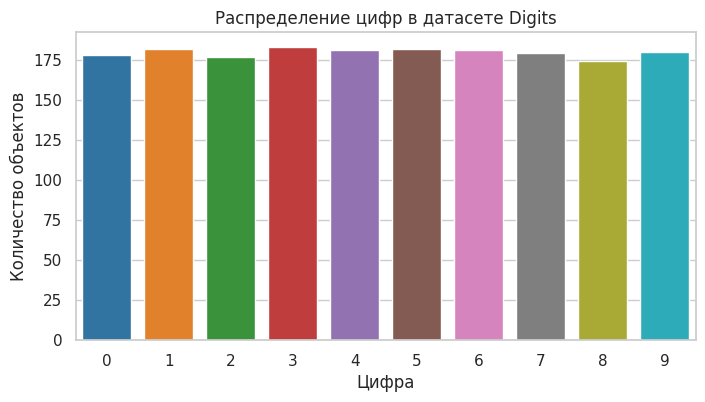

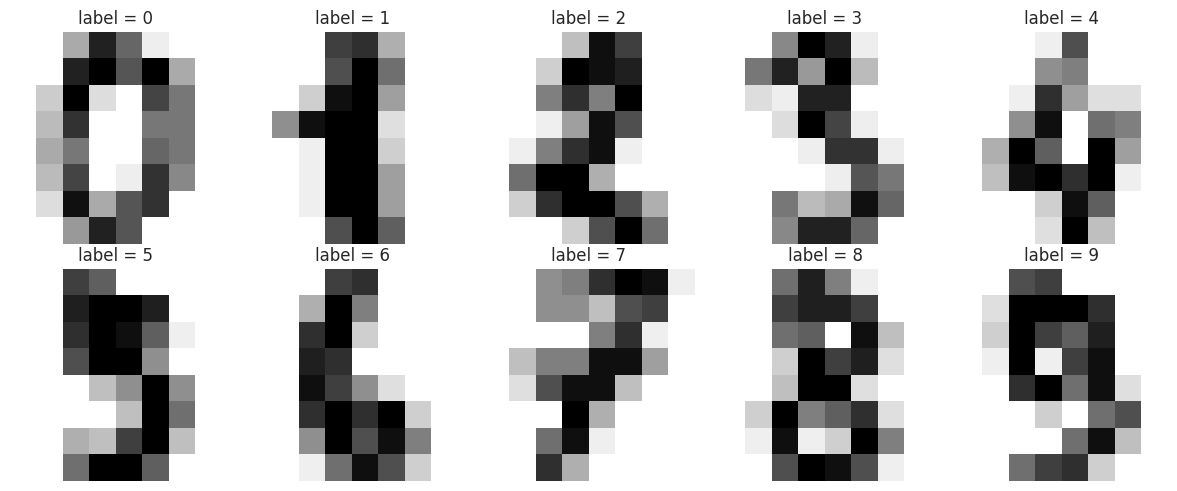

In [6]:
print("Информация о датасете:\n")
df_digits.info()

print("\nРаспределение классов:\n")
class_counts = df_digits["target_name"].value_counts().sort_index()
display(class_counts.to_frame(name="count"))

plt.figure(figsize=(8, 4))
sns.countplot(data=df_digits, x="target_name", hue="target_name", palette="tab10", legend=False)
plt.title("Распределение цифр в датасете Digits")
plt.xlabel("Цифра")
plt.ylabel("Количество объектов")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[idx], cmap="gray_r")
    ax.set_title(f"label = {digits.target[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## PCA: снижение размерности и визуализация

Сначала изучается, какую долю дисперсии объясняют главные компоненты.
После этого выбирается минимальное число компонент, сохраняющее не менее `95%` информации,
и строится двумерная проекция для визуального анализа классов.

Отдельно выполняется обратное восстановление изображений после `PCA`,
чтобы увидеть, насколько заметна потеря информации после сжатия.

Число компонент для 95% накопленной дисперсии: 29


,component,explained_variance_ratio,cumulative_variance
0,1,0.148906,0.148906
1,2,0.136188,0.285094
2,3,0.117946,0.403040
3,4,0.084100,0.487139
4,5,0.057824,0.544964
5,6,0.049169,0.594133
6,7,0.043160,0.637293
7,8,0.036614,0.673906
8,9,0.033532,0.707439
9,10,0.030788,0.738227


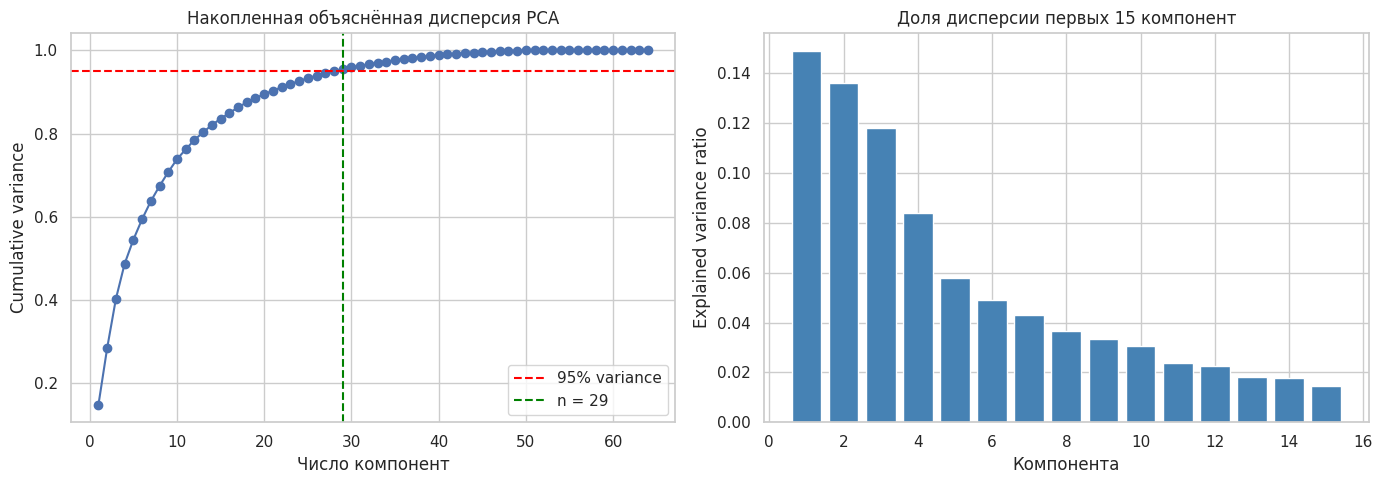

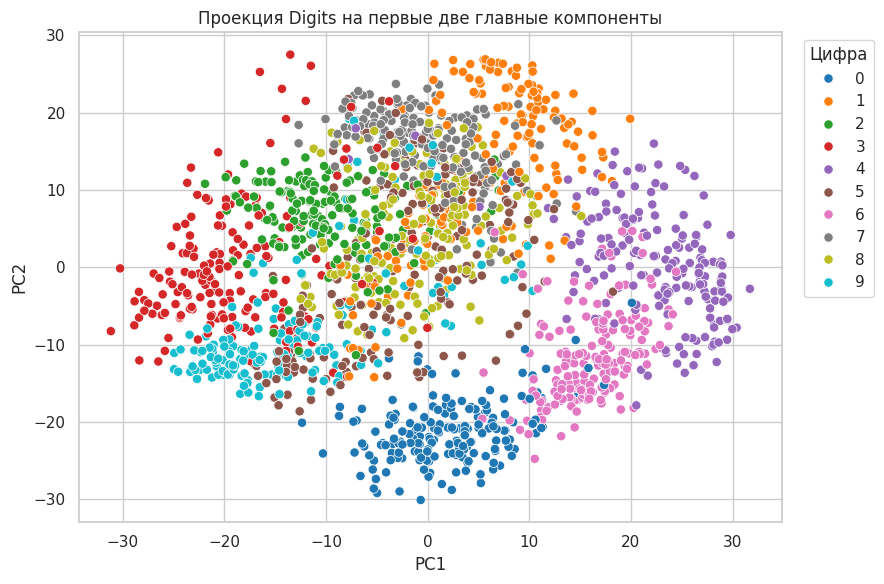

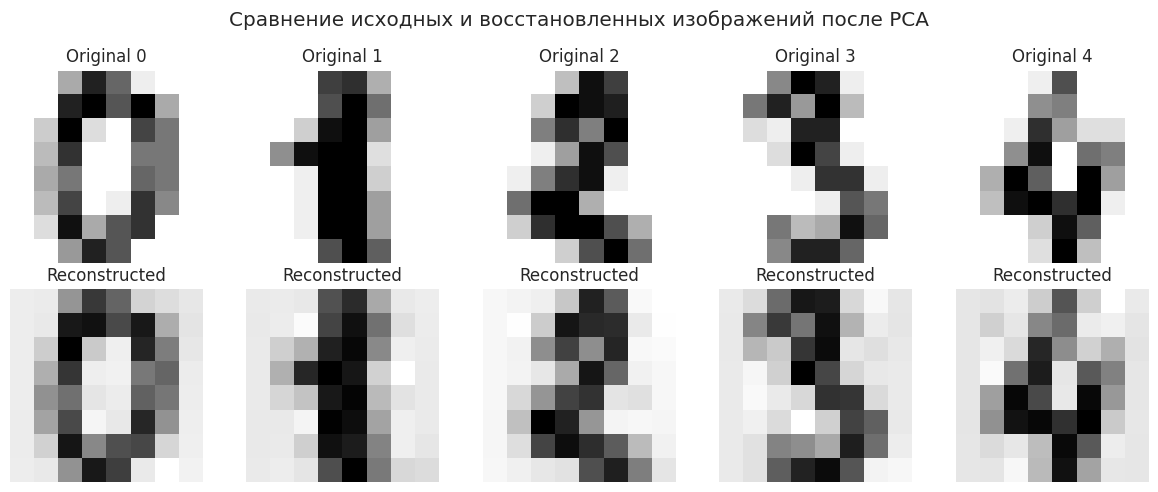

In [7]:
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

pca_full = PCA()
pca_full.fit(X)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.searchsorted(cumulative_variance, 0.95) + 1

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)
df_pca = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
df_pca["digit"] = y.astype(str)

pca_reconstruction = PCA(n_components=n_components_95, random_state=42)
X_reduced = pca_reconstruction.fit_transform(X)
X_reconstructed = pca_reconstruction.inverse_transform(X_reduced)

variance_df = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_variance": cumulative_variance,
    }
)

print(f"Число компонент для 95% накопленной дисперсии: {n_components_95}")
display(variance_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(variance_df["component"], variance_df["cumulative_variance"], marker="o")
axes[0].axhline(0.95, color="red", linestyle="--", label="95% variance")
axes[0].axvline(n_components_95, color="green", linestyle="--", label=f"n = {n_components_95}")
axes[0].set_title("Накопленная объяснённая дисперсия PCA")
axes[0].set_xlabel("Число компонент")
axes[0].set_ylabel("Cumulative variance")
axes[0].legend()

axes[1].bar(variance_df["component"].head(15), variance_df["explained_variance_ratio"].head(15), color="steelblue")
axes[1].set_title("Доля дисперсии первых 15 компонент")
axes[1].set_xlabel("Компонента")
axes[1].set_ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="digit", palette="tab10", s=45)
plt.title("Проекция Digits на первые две главные компоненты")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Цифра", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

sample_indices = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(2, len(sample_indices), figsize=(12, 5))
for col_idx, sample_idx in enumerate(sample_indices):
    axes[0, col_idx].imshow(X[sample_idx].reshape(8, 8), cmap="gray_r")
    axes[0, col_idx].set_title(f"Original {y[sample_idx]}")
    axes[0, col_idx].axis("off")

    axes[1, col_idx].imshow(X_reconstructed[sample_idx].reshape(8, 8), cmap="gray_r")
    axes[1, col_idx].set_title("Reconstructed")
    axes[1, col_idx].axis("off")

plt.suptitle("Сравнение исходных и восстановленных изображений после PCA")
plt.tight_layout()
plt.show()

## Нейронная сеть прямого распространения: классификация

Теперь сравниваются две модели:

- `MLPClassifier` на исходных признаках после стандартизации;
- `MLPClassifier` после стандартизации и снижения размерности через `PCA`.

Такой эксперимент показывает, насколько сильно сжатие пространства признаков
влияет на итоговое качество многоклассовой классификации.

Лучшие параметры модели без PCA:
{'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64,)}

Лучшие параметры модели с PCA:
{'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (128, 64)}

Число компонент PCA после отбора 95% дисперсии: 40

Сравнение моделей:


,Модель,Accuracy,Precision_macro,Recall_macro,F1_macro,Число признаков,Лучшие параметры
1,PCA + MLPClassifier,0.9694,0.9702,0.9692,0.9694,40,"{'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes..."
0,MLPClassifier,0.9583,0.9589,0.9581,0.9580,64,"{'mlp__alpha': 0.0001, 'mlp__hidden_layer_size..."


MLPClassifier на исходных признаках:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.89      0.89        36
           2       0.97      1.00      0.99        35
           3       0.97      0.97      0.97        37
           4       1.00      0.97      0.99        36
           5       0.97      0.97      0.97        37
           6       0.97      0.94      0.96        36
           7       0.97      1.00      0.99        36
           8       0.94      0.86      0.90        35
           9       0.90      1.00      0.95        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360

PCA + MLPClassifier:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.95      0.97      0.96        36
           2      

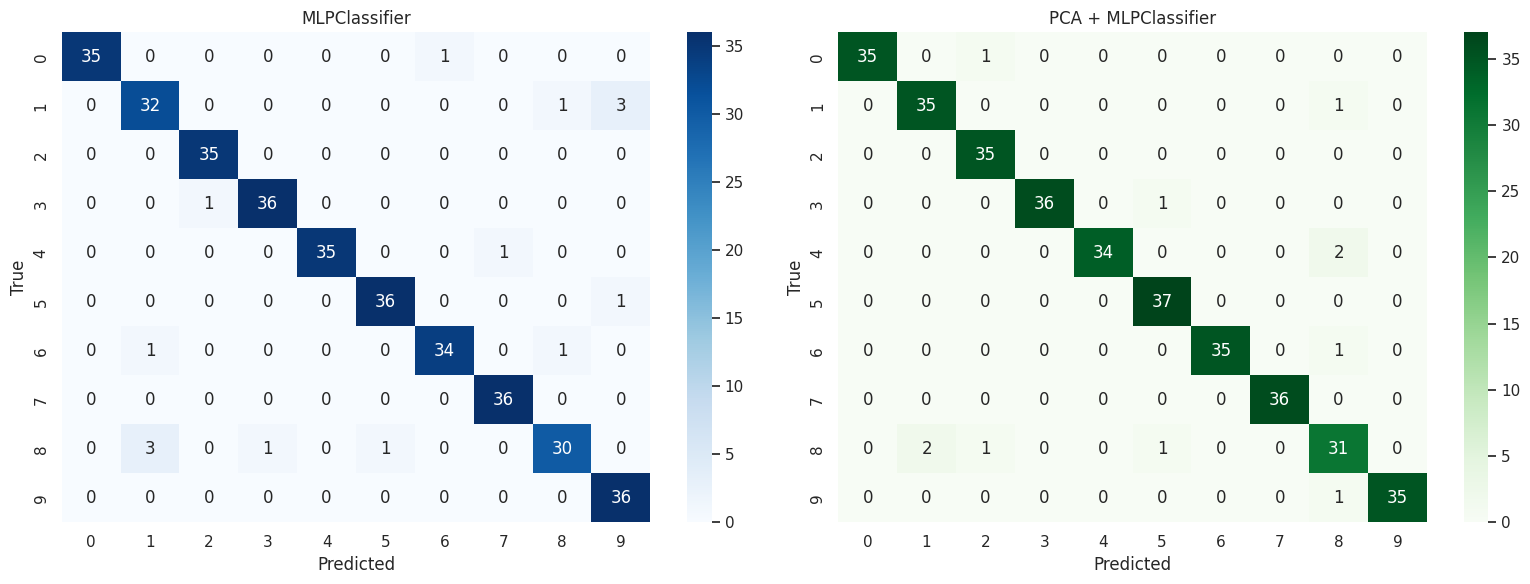

In [8]:
def evaluate_classifier(model_name, fitted_model, X_test_data, y_test_data):
    y_pred = fitted_model.predict(X_test_data)
    result = {
        "Модель": model_name,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision_macro": precision_score(y_test_data, y_pred, average="macro"),
        "Recall_macro": recall_score(y_test_data, y_pred, average="macro"),
        "F1_macro": f1_score(y_test_data, y_pred, average="macro"),
    }
    return result, y_pred


mlp_base_params = {
    "activation": "relu",
    "solver": "adam",
    "max_iter": 300,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 20,
    "random_state": 42,
    "learning_rate_init": 1e-3,
}

pipeline_raw = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(**mlp_base_params)),
    ]
)

pipeline_pca = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("mlp", MLPClassifier(**mlp_base_params)),
    ]
)

param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "mlp__alpha": [1e-4, 1e-3],
}

grid_raw = GridSearchCV(
    pipeline_raw,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
)
grid_raw.fit(X_train, y_train)
best_raw = grid_raw.best_estimator_

grid_pca = GridSearchCV(
    pipeline_pca,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
)
grid_pca.fit(X_train, y_train)
best_pca = grid_pca.best_estimator_

result_raw, y_pred_raw = evaluate_classifier("MLPClassifier", best_raw, X_test, y_test)
result_pca, y_pred_pca = evaluate_classifier("PCA + MLPClassifier", best_pca, X_test, y_test)

result_raw["Число признаков"] = X_train.shape[1]
result_raw["Лучшие параметры"] = str(grid_raw.best_params_)

result_pca["Число признаков"] = int(best_pca.named_steps["pca"].n_components_)
result_pca["Лучшие параметры"] = str(grid_pca.best_params_)

results_df = pd.DataFrame([result_raw, result_pca]).sort_values(by=["Accuracy", "F1_macro"], ascending=False)
metric_columns = ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
results_display = results_df.copy()
results_display[metric_columns] = results_display[metric_columns].round(4)

print("Лучшие параметры модели без PCA:")
print(grid_raw.best_params_)
print("\nЛучшие параметры модели с PCA:")
print(grid_pca.best_params_)
print(f"\nЧисло компонент PCA после отбора 95% дисперсии: {int(best_pca.named_steps['pca'].n_components_)}")

print("\nСравнение моделей:")
display(results_display)

print("MLPClassifier на исходных признаках:\n")
print(classification_report(y_test, y_pred_raw))
print("PCA + MLPClassifier:\n")
print(classification_report(y_test, y_pred_pca))

cm_raw = confusion_matrix(y_test, y_pred_raw)
cm_pca = confusion_matrix(y_test, y_pred_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("MLPClassifier")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("PCA + MLPClassifier")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

## Вывод

По результатам запуска `PCA + MLPClassifier` показал лучшее качество, чем `MLPClassifier`
на исходных признаках: `Accuracy = 0.9694` против `0.9583`, а `F1_macro = 0.9694`
против `0.9580`. Это означает, что в данном случае снижение размерности не только не ухудшило
классификацию, но и помогло модели лучше обобщать на тестовой выборке.

Важно правильно интерпретировать числа компонент в двух частях ноутбука:

- в исследовательской части `PCA` на исходных пиксельных значениях потребовал `29` компонент для `95%` дисперсии;
- в классификационном pipeline после `StandardScaler` модель с `PCA(n_components=0.95)` сохранила `40` компонент.

Это не ошибка. После стандартизации структура дисперсии меняется, поэтому для сохранения тех же `95%`
информации может понадобиться другое число компонент.

Содержательно результаты согласуются с графиками:

- первые главные компоненты действительно улавливают основную структуру изображений;
- восстановленные после `PCA` изображения сохраняют форму цифр;
- матрицы ошибок показывают, что основные затруднения остаются между визуально похожими цифрами,
  но модель с `PCA` ошибается немного реже.

Итог: на датасете `Digits` применение `PCA` перед `MLPClassifier` оказалось оправданным,
поскольку позволило сократить пространство признаков и одновременно немного улучшить качество классификации.